# ==========================================================
# Notebook 06 : CNN Model Training
# EmotionSense AI Pro
# ==========================================================

Speech Emotion Recognition using
Convolutional Neural Networks (CNN)

Dataset:
RAVDESS

Author:
Jakkula Jayanthi

In [35]:
import os
import numpy as np
import pandas as pd
import librosa
import joblib
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.utils import to_categorical

from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.21.0


In [36]:
dataset_path = "../datasets/RAVDESS"

print(dataset_path)

../datasets/RAVDESS


In [37]:
emotion_dict = {
    "01": "Neutral",
    "02": "Calm",
    "03": "Happy",
    "04": "Sad",
    "05": "Angry",
    "06": "Fearful",
    "07": "Disgust",
    "08": "Surprised"
}

emotion_dict

{'01': 'Neutral',
 '02': 'Calm',
 '03': 'Happy',
 '04': 'Sad',
 '05': 'Angry',
 '06': 'Fearful',
 '07': 'Disgust',
 '08': 'Surprised'}

In [38]:
sample_file = os.path.join(
    dataset_path,
    "Actor_01",
    "03-01-01-01-01-01-01.wav"
)

print(sample_file)

../datasets/RAVDESS\Actor_01\03-01-01-01-01-01-01.wav


In [39]:
def extract_mfcc(file_path):

    signal, sample_rate = librosa.load(
        file_path,
        sr=22050
    )

    signal = librosa.util.fix_length(
        signal,
        size=22050 * 3
    )

    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=sample_rate,
        n_mfcc=40
    )

    return mfcc

In [40]:
sample_mfcc = extract_mfcc(sample_file)

print("MFCC Shape :", sample_mfcc.shape)

MFCC Shape : (40, 130)


In [41]:
X = []
y = []

for actor in sorted(os.listdir(dataset_path)):

    actor_path = os.path.join(dataset_path, actor)

    if not os.path.isdir(actor_path):
        continue

    for file in os.listdir(actor_path):

        if not file.endswith(".wav"):
            continue

        file_path = os.path.join(actor_path, file)

        emotion_code = file.split("-")[2]

        emotion = emotion_dict[emotion_code]

        mfcc = extract_mfcc(file_path)

        X.append(mfcc)

        y.append(emotion)

In [42]:
X = np.array(X)
y = np.array(y)

print("X Shape :", X.shape)
print("y Shape :", y.shape)

X Shape : (1440, 40, 130)
y Shape : (1440,)


In [43]:
print("First Sample Shape :", X[0].shape)

print("First Label :", y[0])

First Sample Shape : (40, 130)
First Label : Neutral


In [44]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

joblib.dump(
    label_encoder,
    "../models/cnn_label_encoder.pkl"
)

print(label_encoder.classes_)

['Angry' 'Calm' 'Disgust' 'Fearful' 'Happy' 'Neutral' 'Sad' 'Surprised']


In [45]:
y_encoded = to_categorical(y_encoded)

print(y_encoded.shape)

(1440, 8)


In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(y_encoded, axis=1)
)

print(X_train.shape)
print(X_test.shape)

(1152, 40, 130)
(288, 40, 130)


In [47]:
X_train = X_train[..., np.newaxis]

X_test = X_test[..., np.newaxis]

print(X_train.shape)
print(X_test.shape)

(1152, 40, 130, 1)
(288, 40, 130, 1)


In [48]:
X_train = X_train / np.max(np.abs(X_train))

X_test = X_test / np.max(np.abs(X_test))

print("Normalization Completed")

Normalization Completed


In [49]:
cnn_model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(40,130,1)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        8,
        activation="softmax"
    )

])

cnn_model.summary()

e:\Internship CodeAlpha\CodeAlpha_MachineLearning\EmotionSense_AI\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 38, 128, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 19, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 17, 62, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 31, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 15872)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     2,031,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,051,592 (7.83 MB)

 Trainable params: 2,051,592 (7.83 MB)

 Non-trainable params: 0 (0.00 B)

In [50]:
cnn_model.compile(

    optimizer="adam",

    loss="categorical_crossentropy",

    metrics=["accuracy"]

)

print("CNN Compiled Successfully")

CNN Compiled Successfully


In [51]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)

In [52]:
history = cnn_model.fit(

    X_train,
    y_train,

    validation_data=(X_test, y_test),

    epochs=30,

    batch_size=32,

    callbacks=[early_stop]

)

Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - accuracy: 0.1432 - loss: 2.0649 - val_accuracy: 0.2431 - val_loss: 2.0412
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.2474 - loss: 1.9433 - val_accuracy: 0.3090 - val_loss: 1.8896
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.3403 - loss: 1.7659 - val_accuracy: 0.3611 - val_loss: 1.7175
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.3976 - loss: 1.6139 - val_accuracy: 0.4132 - val_loss: 1.6529
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.4314 - loss: 1.4935 - val_accuracy: 0.3854 - val_loss: 1.5749
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.4948 - loss: 1.3365 - val_accuracy: 0.4479 - val_loss: 1.5042
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.5512 - loss: 1.2256 - val_accuracy: 0.4306 - val_loss: 1.5042
Epoch 8/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.5929 - loss: 1.1328 - val_accuracy: 0.4583 - v

In [53]:
test_loss, test_accuracy = cnn_model.evaluate(X_test, y_test)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5278 - loss: 1.2990
Test Loss : 1.2989778518676758
Test Accuracy : 0.5277777910232544


In [54]:
cnn_model.save("../models/cnn_emotion_model.keras")

print("CNN Model Saved Successfully!")

CNN Model Saved Successfully!


In [55]:
import pandas as pd

history_df = pd.DataFrame(history.history)

history_df.to_csv(
    "../outputs/cnn_training_history.csv",
    index=False
)

print("Training history saved.")

Training history saved.


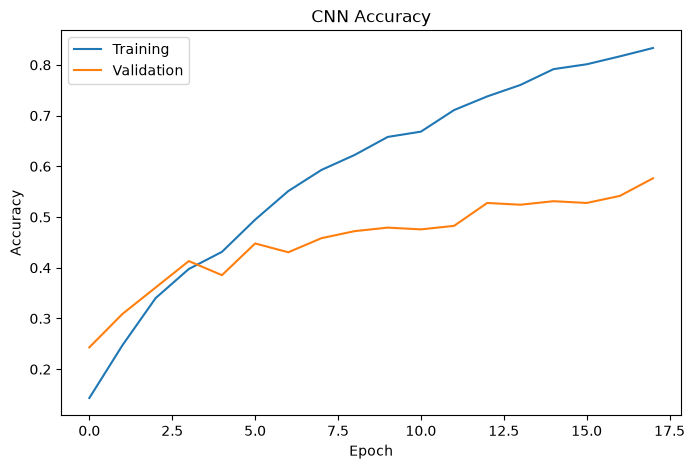

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training")

plt.plot(history.history["val_accuracy"], label="Validation")

plt.title("CNN Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

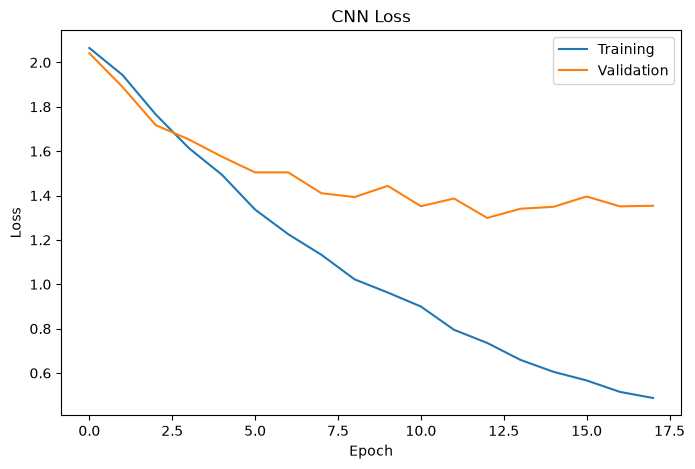

In [57]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training")

plt.plot(history.history["val_loss"], label="Validation")

plt.title("CNN Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [58]:
from sklearn.metrics import classification_report
import numpy as np

y_pred = cnn_model.predict(X_test)

y_pred = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_
    )
)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
              precision    recall  f1-score   support

       Angry       0.60      0.66      0.62        38
        Calm       0.56      0.82      0.67        38
     Disgust       0.56      0.50      0.53        38
     Fearful       0.55      0.46      0.50        39
       Happy       0.44      0.44      0.44        39
     Neutral       0.40      0.32      0.35        19
         Sad       0.38      0.26      0.31        38
   Surprised       0.59      0.67      0.63        39

    accuracy                           0.53       288
   macro avg       0.51      0.51      0.51       288
weighted avg       0.52      0.53      0.52       288



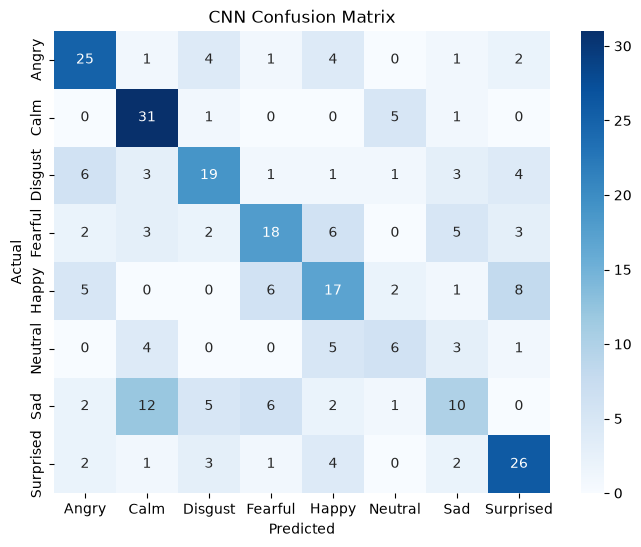

In [60]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("CNN Confusion Matrix")

plt.show()

In [61]:
cnn_model.save("../models/cnn_model.keras")

print("CNN model saved successfully!")

CNN model saved successfully!
